<a href="https://colab.research.google.com/github/lael0805-ctrl/oss2026_lab1/blob/main/chest_xray_classification_starter_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 흉부 X-ray 폐렴 분류 — 전이학습(Transfer Learning) 스타터 노트북

**목적**: ResNet18 전이학습으로 흉부 X-ray 이미지를 정상(NORMAL) / 폐렴(PNEUMONIA)으로 분류하는 이미지 분류 실습

**준비물**: Kaggle 계정 + API 토큰 (Kaggle 로그인 → 우측 상단 프로필 → Settings → API → "Create New Token" 누르면 `kaggle.json` 파일이 다운로드됩니다)

**사용 데이터셋**: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) — 정상/폐렴 흉부 X-ray 약 5,800장

**진행 순서**: 환경설정 → 데이터 다운로드 → 데이터 로더 구성 → 샘플 확인 → 모델 정의 → 학습 → 평가 → (선택) fine-tuning → 모델 저장

---
colab에서 실행할 때: 상단 메뉴 `런타임(Runtime)` → `런타임 유형 변경(Change runtime type)` → 하드웨어 가속기를 **GPU**로 설정하고 시작하세요.

## 1. 환경설정 및 GPU 확인

In [ ]:
!pip install -q -U "kaggle>=1.8.0" scikit-learn
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1

import torch
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 그래프(confusion matrix 등)에 한글 라벨이 깨지지 않도록 나눔고딕 폰트를 등록해요
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("GPU 사용 가능:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용할 device:", device)

GPU 사용 가능: True
사용할 device: cuda


## 2. Kaggle API 토큰 설정

Kaggle이 최근 토큰 발급 방식을 바꿨어요 — 이제 `kaggle.json` 파일을 다운로드하는 대신,
Settings → API Tokens에서 Generate를 누르면 화면에 `KGAT_...`로 시작하는 토큰 문자열이 **딱 한 번** 보여요.
그 값을 복사해서 아래 셀의 `YOUR_TOKEN_HERE` 자리에 붙여넣고 실행하면 됩니다.

> 토큰을 놓쳤거나 다시 필요하면, 같은 화면에서 새 토큰을 또 Generate하면 돼요 (기존 토큰들은 그대로 살아있어요).

In [ ]:
import os

# 아래 따옴표 안에 Kaggle에서 복사한 토큰 값을 붙여넣으세요 (KGAT_로 시작하는 문자열)
os.environ['KAGGLE_API_TOKEN'] = "KGAT_56b031bf0f0b877a37258530d4ab399e"

assert os.environ['KAGGLE_API_TOKEN'] != "YOUR_TOKEN_HERE", \
    "토큰을 아직 안 바꾸셨어요! 위 줄에 실제 복사한 토큰 값을 붙여넣어주세요."

**만약 옛날 방식대로 `kaggle.json` 파일이 다운로드됐다면**, 아래 셀을 대신 쓰시면 돼요 (둘 중 하나만 실행하면 됩니다).

In [ ]:
from google.colab import files
print("kaggle.json 파일을 업로드해주세요")
uploaded = files.upload()
#
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

kaggle.json 파일을 업로드해주세요


KeyboardInterrupt: 

## 3. 데이터셋 다운로드 및 압축 해제

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content --force
!unzip -q /content/chest-xray-pneumonia.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:59<00:00, 20.6MB/s]



압축을 풀면 폴더 구조가 `chest_xray/chest_xray/train/...` 처럼 한 겹 더 중첩되어 있는 경우가 있어요.
아래 코드가 `train` 폴더를 자동으로 찾아서 실제 데이터 경로를 잡아줍니다.

In [ ]:
import glob

candidates = glob.glob('/content/data/**/train', recursive=True)
assert len(candidates) > 0, "train 폴더를 찾지 못했어요. /content/data 구조를 직접 확인해보세요."
data_root = candidates[0].rsplit('/train', 1)[0]
print("데이터 경로:", data_root)
!ls "$data_root"

데이터 경로: /content/data/chest_xray
chest_xray  __MACOSX  test  train  val


## 4. 데이터 로더 구성

> 참고: 원본 데이터셋의 `val` 폴더는 16장밖에 없어서 검증용으로는 좀 부족해요.
> 우선은 그대로 써보고, 나중에 여유가 되면 `train`에서 일부를 떼어 검증셋을 다시 만들어보는 것도 좋은 연습이 돼요.

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

IMG_SIZE = 224
BATCH_SIZE = 32

# ImageNet으로 사전학습된 모델을 쓸 거라, 정규화 값도 ImageNet 기준을 그대로 사용해요
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),      # 데이터 증강: 좌우 반전
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(f"{data_root}/train", transform=train_transform)
val_dataset   = datasets.ImageFolder(f"{data_root}/val",   transform=eval_transform)
test_dataset  = datasets.ImageFolder(f"{data_root}/test",  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("클래스:", train_dataset.classes)  # 0: NORMAL, 1: PNEUMONIA 순서로 잡힐 거예요
print(f"train: {len(train_dataset)}장 / val: {len(val_dataset)}장 / test: {len(test_dataset)}장")

클래스: ['NORMAL', 'PNEUMONIA']
train: 5216장 / val: 16장 / test: 624장


## 5. 샘플 이미지 확인

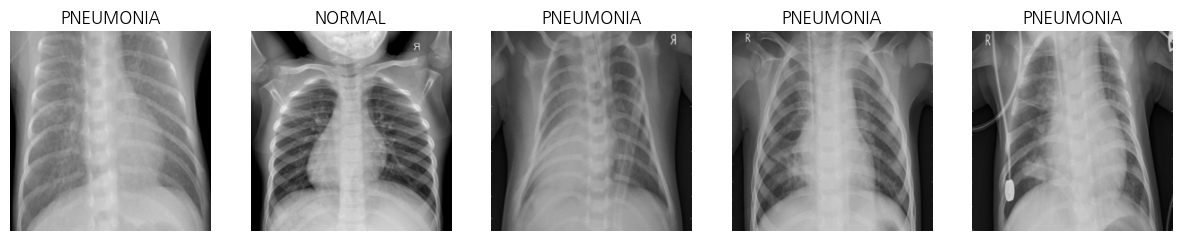

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def unnormalize(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(unnormalize(images[i]))
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis('off')
plt.show()

## 6. 모델 정의 — ResNet18 전이학습

ImageNet으로 미리 학습된 ResNet18을 가져와서, 마지막 분류 레이어만 우리 문제(정상/폐렴 2개 클래스)에 맞게 바꿔줍니다.
백본(backbone)은 우선 얼려서(freeze) 마지막 레이어만 학습시켜요 — 데이터가 적어도 빠르게 학습되고 과적합도 덜해요.

In [ ]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 백본 전체를 얼려서 기존에 학습된 특징 추출 능력은 그대로 유지
for param in model.parameters():
    param.requires_grad = False

# 마지막 fully-connected layer만 우리 클래스 수에 맞게 교체 (이 레이어만 새로 학습됨)
num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 193MB/s]


Linear(in_features=512, out_features=2, bias=True)


## 7. 손실함수 & 옵티마이저

이 데이터셋은 NORMAL보다 PNEUMONIA 이미지가 train 기준 약 3배 더 많아요.
그대로 학습하면 모델이 "애매하면 일단 폐렴"이라고 찍는 쪽으로 치우치기 쉬워요 (실제로 처음 학습했을 때 NORMAL recall이 0.48밖에 안 나왔던 이유이기도 해요).
개수가 적은 클래스(NORMAL)에 더 큰 가중치를 줘서 이 불균형을 보정해줍니다.

In [ ]:
import torch.optim as optim
from collections import Counter

# 클래스별 이미지 개수 확인
class_counts = Counter(train_dataset.targets)
print("클래스별 개수:", {train_dataset.classes[k]: v for k, v in class_counts.items()})

# 개수가 적은 클래스일수록 더 큰 가중치를 갖도록 계산 (전체 개수 / 해당 클래스 개수)
total = sum(class_counts.values())
weights = [total / class_counts[i] for i in range(len(train_dataset.classes))]
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print("적용할 클래스 가중치:", dict(zip(train_dataset.classes, [round(w, 2) for w in weights])))

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)  # 얼리지 않은 fc 레이어만 학습

클래스별 개수: {'NORMAL': 1341, 'PNEUMONIA': 3875}
적용할 클래스 가중치: {'NORMAL': 3.89, 'PNEUMONIA': 1.35}


## 8. 학습 루프

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


NUM_EPOCHS = 5  # 가볍게 연습하는 용도라 5 epoch면 충분히 감을 잡을 수 있어요

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    print(f"[Epoch {epoch}/{NUM_EPOCHS}] "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

[Epoch 1/5] train_loss=0.2876 train_acc=0.8771 | val_loss=0.3126 val_acc=0.8750
[Epoch 2/5] train_loss=0.1997 train_acc=0.9275 | val_loss=0.2974 val_acc=0.8750
[Epoch 3/5] train_loss=0.1658 train_acc=0.9348 | val_loss=0.3661 val_acc=0.8750
[Epoch 4/5] train_loss=0.1560 train_acc=0.9377 | val_loss=0.3496 val_acc=0.8750
[Epoch 5/5] train_loss=0.1423 train_acc=0.9444 | val_loss=0.2700 val_acc=0.8750


## 9. 테스트셋 평가 — Accuracy, Recall, Confusion Matrix

의료 데이터에서는 정확도만 보면 안 돼요. "폐렴인데 정상으로 오진(False Negative)"하는 게 가장 위험하기 때문에,
**recall(재현율)** — 실제 폐렴 환자 중 몇 %를 제대로 잡아냈는지 — 을 꼭 함께 확인해야 해요.

              precision    recall  f1-score   support

      NORMAL       0.94      0.75      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624



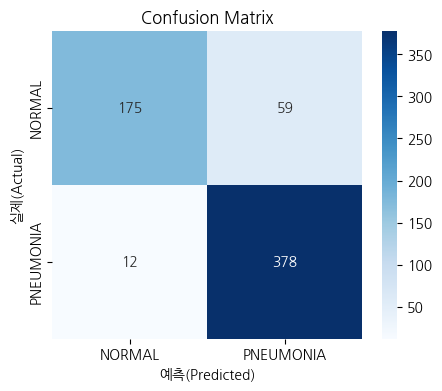

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('예측(Predicted)')
plt.ylabel('실제(Actual)')
plt.title('Confusion Matrix')
plt.show()

## 10. (선택) 전체 레이어 Fine-tuning

기본 학습 결과가 만족스럽지 않다면, 얼려뒀던 백본도 풀어서(unfreeze) 아주 작은 learning rate로 전체를 추가 학습시켜볼 수 있어요.
단, 이 단계부터는 과적합 위험이 커지니 val_acc를 잘 지켜보면서 진행하세요.

In [ ]:
# for param in model.parameters():
#     param.requires_grad = True
#
# optimizer = optim.Adam(model.parameters(), lr=1e-5)  # 훨씬 작은 lr 사용
#
# for epoch in range(1, 4):
#     train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
#     val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
#     print(f"[Fine-tune {epoch}] train_acc={train_acc:.4f} val_acc={val_acc:.4f}")

## 11. 모델 저장

In [ ]:
torch.save(model.state_dict(), '/content/resnet18_chest_xray.pt')
print("모델 저장 완료: /content/resnet18_chest_xray.pt")

# Colab 세션이 끝나면 /content 는 사라지니, 계속 쓰고 싶으면 구글드라이브에 복사해두세요.
# from google.colab import drive
# drive.mount('/content/drive')
# !cp /content/resnet18_chest_xray.pt /content/drive/MyDrive/

모델 저장 완료: /content/resnet18_chest_xray.pt


## 다음에 시도해볼 것들

- **다른 pretrained 모델**로 바꿔보기 (`resnet18` → `efficientnet_b0`, `resnet50` 등) 하고 성능 비교
- val 셋이 너무 작으니, `train`에서 일부를 떼어 새로운 val 셋 만들어보기
- 데이터 증강(augmentation) 기법 추가해보고 성능 변화 관찰 (RandomRotation, ColorJitter 등)
- 같은 파이프라인으로 **Brain Tumor MRI Dataset**(4-class) 등 다른 의료 영상 데이터셋에도 적용해보기
- Grad-CAM으로 모델이 이미지의 어느 부분을 보고 판단했는지 시각화해보기 (설명가능한 AI, XAI 맛보기)